<a href="https://colab.research.google.com/github/naveen03-tech/CodSoft-Machine-Learning-internship/blob/main/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
df = pd.read_csv("spam.csv", encoding="latin-1")

In [12]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [13]:
df.shape

(5572, 5)

In [15]:
df.drop_duplicates()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [16]:
df.isnull()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,False,False,True,True,True
1,False,False,True,True,True
2,False,False,True,True,True
3,False,False,True,True,True
4,False,False,True,True,True
...,...,...,...,...,...
5567,False,False,True,True,True
5568,False,False,True,True,True
5569,False,False,True,True,True
5570,False,False,True,True,True


In [17]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [18]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [19]:
df.tail()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN
5571,ham,Rofl. Its true to its name,NaN,NaN,NaN


In [ ]:
# Naive Bayes

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("spam.csv", encoding="latin-1")

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df['label'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

tfidf = TfidfVectorizer(stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

message = ["Congratulations! You won a free ticket. Call now to claim your prize."]

message_tfidf = tfidf.transform(message)

prediction = model.predict(message_tfidf)

if prediction[0] == 1:
    print("\nSpam Message")
else:
    print("\nLegitimate Message")

Accuracy: 0.9668161434977578

Confusion Matrix:

[[965   0]
 [ 37 113]]

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115


Spam Message


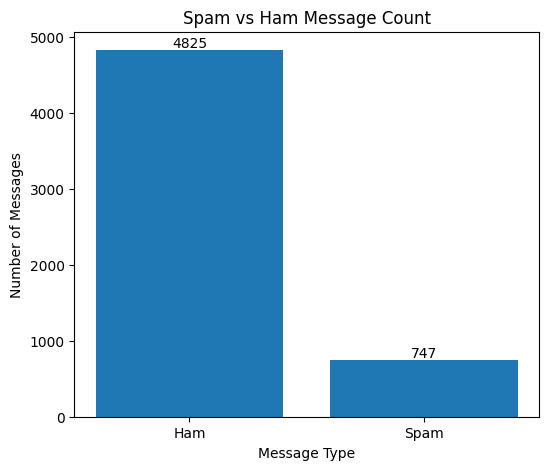

In [25]:
import matplotlib.pyplot as plt

counts = df['label'].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(['Ham', 'Spam'], [counts[0], counts[1]])
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')
plt.title('Spam vs Ham Message Count')

for i, value in enumerate([counts[0], counts[1]]):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

In [ ]:
# Support Vector Machine

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("spam.csv", encoding="latin-1")

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df['label'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

tfidf = TfidfVectorizer(stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = SVC(kernel='linear')

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

message = ["Congratulations! You won a free ticket. Call now to claim your prize."]

message_tfidf = tfidf.transform(message)

prediction = model.predict(message_tfidf)

if prediction[0] == 1:
    print("\nSpam Message")
else:
    print("\nLegitimate Message")

Accuracy: 0.979372197309417

Confusion Matrix:

[[961   4]
 [ 19 131]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.97      0.87      0.92       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115


Spam Message



 Hard Margin SVM (C = 1000)
Hyperplane Equation:
0.0001 * x1 + -0.0006 * x2 + -1.0001 = 0


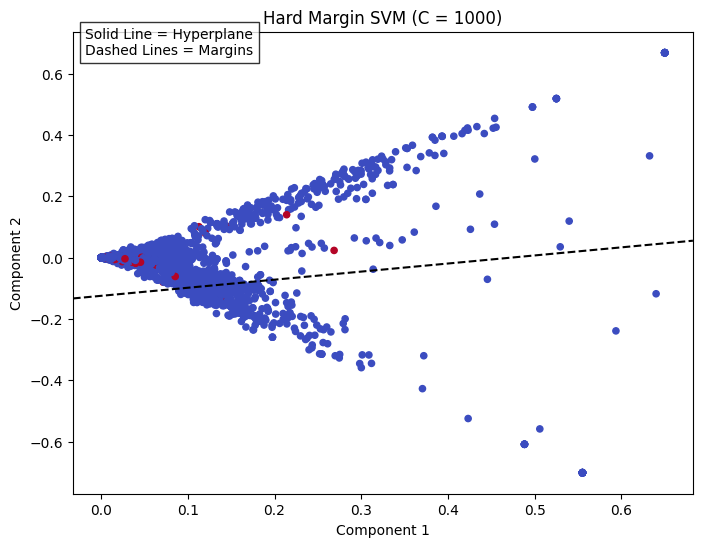


 Soft Margin SVM (C = 0.1)
Hyperplane Equation:
-0.0004 * x1 + 0.0004 * x2 + -0.9999 = 0


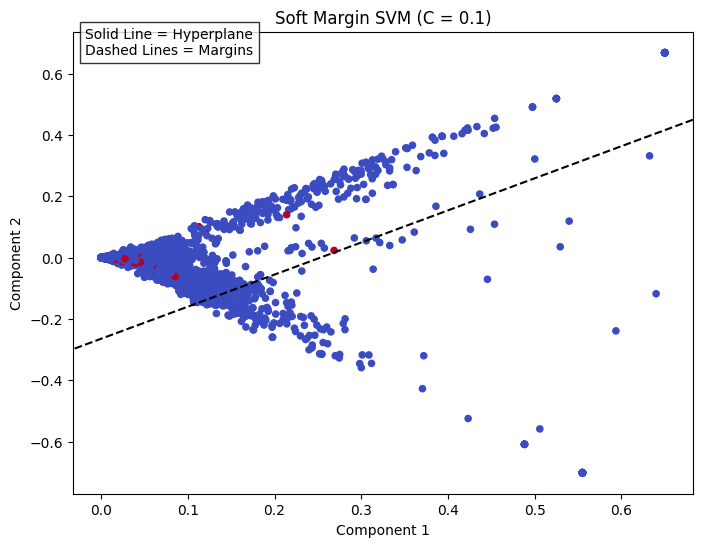

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import SVC

df = pd.read_csv("spam.csv", encoding="latin-1")

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df['label'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['message']
y = df['label']

tfidf = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf.fit_transform(X)

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_tfidf)

hard_svm = SVC(kernel='linear', C=1000)
hard_svm.fit(X_2d, y)

soft_svm = SVC(kernel='linear', C=0.1)
soft_svm.fit(X_2d, y)

def plot_svm(model, title):
    plt.figure(figsize=(8,6))

    plt.scatter(
        X_2d[:,0],
        X_2d[:,1],
        c=y,
        cmap='coolwarm',
        s=20
    )

    ax = plt.gca()

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)

    YY, XX = np.meshgrid(yy, xx)

    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(
        XX,
        YY,
        Z,
        levels=[-1, 0, 1],
        colors='black',
        linestyles=['--', '-', '--']
    )

    w = model.coef_[0]
    b = model.intercept_[0]

    print("\n", title)
    print("Hyperplane Equation:")
    print(f"{w[0]:.4f} * x1 + {w[1]:.4f} * x2 + {b:.4f} = 0")

    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.title(title)

    plt.text(
        0.02,
        0.95,
        "Solid Line = Hyperplane\nDashed Lines = Margins",
        transform=ax.transAxes,
        bbox=dict(facecolor='white', alpha=0.8)
    )

    plt.show()

plot_svm(hard_svm, "Hard Margin SVM (C = 1000)")
plot_svm(soft_svm, "Soft Margin SVM (C = 0.1)")

Naive Bayes Accuracy: 0.9668161434977578
SVM Accuracy: 0.979372197309417


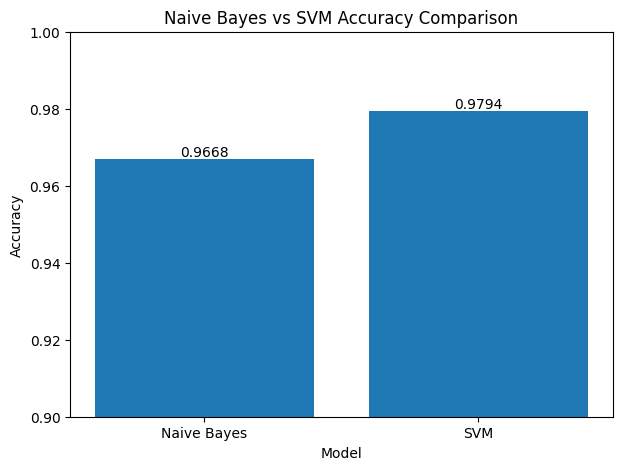


Best Model: Support Vector Machine (SVM)


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

df = pd.read_csv("spam.csv", encoding="latin-1")

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df['label'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

tfidf = TfidfVectorizer(stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)
nb_accuracy = accuracy_score(y_test, nb_pred)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)
svm_accuracy = accuracy_score(y_test, svm_pred)

print("Naive Bayes Accuracy:", nb_accuracy)
print("SVM Accuracy:", svm_accuracy)

models = ['Naive Bayes', 'SVM']
accuracies = [nb_accuracy, svm_accuracy]

plt.figure(figsize=(7,5))
bars = plt.bar(models, accuracies)

plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.title('Naive Bayes vs SVM Accuracy Comparison')
plt.ylim(0.9, 1.0)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.4f}',
        ha='center',
        va='bottom'
    )

plt.show()


if svm_accuracy > nb_accuracy:
    print("\nBest Model: Support Vector Machine (SVM)")
else:
    print("\nBest Model: Naive Bayes")